In [1]:
# Create two dataframes named `df` and `df_1S`, then combine them.
# - df       := cleaned redmi6.csv
# - df_1S    := cleaned redmi6_reviews_star1.csv
# Finally, save a combined CSV.

import re
import numpy as np
import pandas as pd

# --- Helpers from previous step ---
def load_csv_robust(path, dtype=str):
    for enc in ["utf-8", "utf-8-sig", "cp1252", "latin1"]:
        try:
            return pd.read_csv(path, dtype=dtype, encoding=enc)
        except Exception:
            continue
    return pd.read_csv(path, dtype=dtype)

def normalize_redmi_token(s: str) -> str:
    return re.sub(r"(?i)\bredmi\s*6\b", "redmi6", s) if isinstance(s, str) else s

def normalize_all_text_columns(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()
    obj_cols = [c for c in df2.columns if df2[c].dtype == object]
    for c in obj_cols:
        df2[c] = df2[c].apply(normalize_redmi_token)
    return df2

def coerce_rating_to_float(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()
    rating_cols = [c for c in df2.columns if c.lower() == "rating"]
    for rc in rating_cols:
        df2[rc] = (
            df2[rc]
            .astype(str)
            .str.extract(r"([-+]?\d*\.?\d+)")[0]
            .astype(float)
        )
    return df2

# Try to use the already-cleaned outputs if they exist; otherwise re-clean from raw files
try:
    df = load_csv_robust("D:\\Private\\Python\\data\\datasets\\redmi6.csv")
    df_1S = load_csv_robust("D:\\Private\\Python\\Tugas\\flipkart_redmi6_reviews.csv")
except Exception:
    df = load_csv_robust("D:\\Private\\Python\\data\\datasets\\redmi6.csv", dtype=str)
    df_1S = load_csv_robust("D:\\Private\\Python\\Tugas\\flipkart_redmi6_reviews.csv", dtype=str)
    df = coerce_rating_to_float(normalize_all_text_columns(df))
    df_1S = coerce_rating_to_float(normalize_all_text_columns(df_1S))

# Ensure any columns from df_1S missing in df are added as NaN (as requested earlier)
missing_cols_for_df = [c for c in df_1S.columns if c not in df.columns]
for c in missing_cols_for_df:
    df[c] = np.nan

# Also ensure any columns from df missing in df_1S are present (so concat aligns)
missing_cols_for_df1S = [c for c in df.columns if c not in df_1S.columns]
for c in missing_cols_for_df1S:
    df_1S[c] = np.nan

# Combine
combined = pd.concat([df, df_1S], ignore_index=True, sort=False)

df.shape, df_1S.shape, combined.shape


((280, 12), (190, 12), (470, 12))

In [2]:
combined

,Review Title,Customer name,Rating,Date,Category,Comments,Useful,Title,Body,Reviewer,Likes,Dislikes
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0 out of 5 stars,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\r...,,NaN,NaN,NaN,NaN,NaN
1,vry small size mobile,Raza ji,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful,NaN,NaN,NaN,NaN,NaN
2,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful,NaN,NaN,NaN,NaN,NaN
3,Value for Money,Amazon Customer,5.0 out of 5 stars,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful,NaN,NaN,NaN,NaN,NaN
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0 out of 5 stars,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
465,NaN,NaN,1,Wasim Raja,NaN,NaN,NaN,Useless product,bad product i am not satisfied,Wasim Raja,0,0
466,NaN,NaN,1,Anita Customer,NaN,NaN,NaN,Horrible,frequently the apps stop working ....,Anita Customer,0,0
467,NaN,NaN,1,Flipkart Customer,NaN,NaN,NaN,Worthless,Battery backup very bad,Flipkart Customer,0,0
468,NaN,NaN,1,Tahseen Kausar Tahseen Kausar,NaN,NaN,NaN,Utterly Disappointed,not lotsoff problem,Tahseen Kausar Tahseen Kausar,0,0


In [3]:
import pandas as pd

# Helper: find a column by case-insensitive name among candidates
def find_col(df: pd.DataFrame, *candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

# 1) Move "title" -> "review title" where review title is NaN/empty
review_title_col = find_col(combined, "Review Title", "review title")
title_col        = find_col(combined, "Title", "title")

if review_title_col and title_col:
    # Treat empty strings as missing too
    rt_is_missing = combined[review_title_col].isna() | (combined[review_title_col].astype(str).str.strip() == "")
    combined.loc[rt_is_missing, review_title_col] = combined.loc[rt_is_missing, title_col]

# 2) Drop column "date" (any case variant)
date_like_cols = [c for c in combined.columns if c.lower() == "date"]
if date_like_cols:
    combined.drop(columns=date_like_cols, inplace=True)

# 3) Move "body" -> "comment" where "customer name" is NaN/empty
#    (be flexible with column name variants)
body_col      = find_col(combined, "Body", "body", "Review Body", "review body", "Content", "content")
comment_col   = find_col(combined, "Comments", "comment")
customer_col  = find_col(combined, "Customer name", "customer", "Customer")

# If there's no comment column, create one (prefer "Comments")
if comment_col is None:
    comment_col = "Comments"
    if comment_col not in combined.columns:
        combined[comment_col] = pd.NA

if body_col and comment_col:
    if customer_col:
        cust_missing = combined[customer_col].isna() | (combined[customer_col].astype(str).str.strip() == "")
        # Fill comment with body where customer is missing and comment is NaN/empty
        to_fill = cust_missing & (combined[comment_col].isna() | (combined[comment_col].astype(str).str.strip() == ""))
        combined.loc[to_fill, comment_col] = combined.loc[to_fill, body_col]
    else:
        # If no customer column is found, do nothing (or remove this guard to always fill)
        pass


In [4]:
combined

,Review Title,Customer name,Rating,Category,Comments,Useful,Title,Body,Reviewer,Likes,Dislikes
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0 out of 5 stars,Display,Another Midrange killer Smartphone by Xiaomi\r...,,NaN,NaN,NaN,NaN,NaN
1,vry small size mobile,Raza ji,3.0 out of 5 stars,Others,All ok but vry small size mobile,7 people found this helpful,NaN,NaN,NaN,NaN,NaN
2,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,Others,Quite good,7 people found this helpful,NaN,NaN,NaN,NaN,NaN
3,Value for Money,Amazon Customer,5.0 out of 5 stars,Display,Redmi has always have been the the king of bud...,2 people found this helpful,NaN,NaN,NaN,NaN,NaN
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0 out of 5 stars,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
465,Useless product,NaN,1,NaN,bad product i am not satisfied,NaN,Useless product,bad product i am not satisfied,Wasim Raja,0,0
466,Horrible,NaN,1,NaN,frequently the apps stop working ....,NaN,Horrible,frequently the apps stop working ....,Anita Customer,0,0
467,Worthless,NaN,1,NaN,Battery backup very bad,NaN,Worthless,Battery backup very bad,Flipkart Customer,0,0
468,Utterly Disappointed,NaN,1,NaN,not lotsoff problem,NaN,Utterly Disappointed,not lotsoff problem,Tahseen Kausar Tahseen Kausar,0,0


In [5]:
# Convert "Rating" like "4.0 out of 5 stars" -> integer in the `combined` DataFrame

import pandas as pd

# Find the Rating column case-insensitively
rating_col = next((c for c in combined.columns if c.lower() == "rating"), None)

if rating_col:
    combined[rating_col] = (
        combined[rating_col]
        .astype(str)
        .str.extract(r"([-+]?\d*\.?\d+)")[0]   # pulls "4.0" from "4.0 out of 5 stars"
        .pipe(pd.to_numeric, errors="coerce")  # -> float (NaN on bad parse)
        .astype("Int64")                       # -> integer (nullable)
    )


In [6]:
combined

,Review Title,Customer name,Rating,Category,Comments,Useful,Title,Body,Reviewer,Likes,Dislikes
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4,Display,Another Midrange killer Smartphone by Xiaomi\r...,,NaN,NaN,NaN,NaN,NaN
1,vry small size mobile,Raza ji,3,Others,All ok but vry small size mobile,7 people found this helpful,NaN,NaN,NaN,NaN,NaN
2,Full display not working in all application.,Vaibhav Patel,3,Others,Quite good,7 people found this helpful,NaN,NaN,NaN,NaN,NaN
3,Value for Money,Amazon Customer,5,Display,Redmi has always have been the the king of bud...,2 people found this helpful,NaN,NaN,NaN,NaN,NaN
4,Not worth for the money,Sudhakaran Wadakkancheri,2,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
465,Useless product,NaN,1,NaN,bad product i am not satisfied,NaN,Useless product,bad product i am not satisfied,Wasim Raja,0,0
466,Horrible,NaN,1,NaN,frequently the apps stop working ....,NaN,Horrible,frequently the apps stop working ....,Anita Customer,0,0
467,Worthless,NaN,1,NaN,Battery backup very bad,NaN,Worthless,Battery backup very bad,Flipkart Customer,0,0
468,Utterly Disappointed,NaN,1,NaN,not lotsoff problem,NaN,Utterly Disappointed,not lotsoff problem,Tahseen Kausar Tahseen Kausar,0,0


In [7]:
# Keep only: Review Title, Rating, Category, Comment (case-insensitive; handles common variants)

import pandas as pd

def find_col(df: pd.DataFrame, *candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

col_review_title = find_col(combined, "Review Title", "review title", "title")
col_rating       = find_col(combined, "Rating", "rating")
col_category     = find_col(combined, "Category", "category")
col_comment      = find_col(combined, "Comments", "comment", "Review Body", "review body", "Body", "body", "Content", "content")

# Build list of columns to keep (only those found)
keep_cols = [c for c in [col_review_title, col_rating, col_category, col_comment] if c is not None]

# Subset combined to only these columns
combined = combined.loc[:, keep_cols].copy()

# (Optional) standardize the column names
rename_map = {}
if col_review_title: rename_map[col_review_title] = "Review Title"
if col_rating:       rename_map[col_rating]       = "Rating"
if col_category:     rename_map[col_category]     = "Category"
if col_comment:      rename_map[col_comment]      = "Comments"
combined.rename(columns=rename_map, inplace=True)


In [8]:
combined

,Review Title,Rating,Category,Comments
0,Another Midrange killer Smartphone by Xiaomi,4,Display,Another Midrange killer Smartphone by Xiaomi\r...
1,vry small size mobile,3,Others,All ok but vry small size mobile
2,Full display not working in all application.,3,Others,Quite good
3,Value for Money,5,Display,Redmi has always have been the the king of bud...
4,Not worth for the money,2,Others,worst product from MI. I am a hardcore fan of ...
...,...,...,...,...
465,Useless product,1,NaN,bad product i am not satisfied
466,Horrible,1,NaN,frequently the apps stop working ....
467,Worthless,1,NaN,Battery backup very bad
468,Utterly Disappointed,1,NaN,not lotsoff problem


In [9]:
# Fill missing Category values using an LLM (Ollama) based on the "Comments" text.
# Allowed categories: battery, display, delivery, camera, others.
# - Uses a clear prompt and captures the raw LLM result.
# - Falls back to simple keyword heuristics if the LLM returns something unexpected.
# - Works on the existing `combined` DataFrame.

import re
import time
import pandas as pd
from tqdm import tqdm
import ollama

# --- Helpers ---
def find_col(df: pd.DataFrame, *candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def normalize_llm_category(s: str) -> str:
    """Normalize LLM outputs (e.g., 'Battery', 'screen') to one of the allowed categories."""
    if not isinstance(s, str):
        return "others"
    t = s.strip().lower()
    # Keep only letters; take first token if multiple words
    t = re.split(r"\s+", t)[0]
    t = re.sub(r"[^a-z]", "", t)

    synonyms = {
        "batteries": "battery",
        "power": "battery",
        "charging": "battery",
        "charge": "battery",
        "backup": "battery",
        "drain": "battery",
        "draining": "battery",

        "screen": "display",
        "lcd": "display",
        "amoled": "display",
        "brightness": "display",
        "touch": "display",
        "touchscreen": "display",
        "pixel": "display",
        "pixels": "display",
        "resolution": "display",

        "shipping": "delivery",
        "courier": "delivery",
        "logistics": "delivery",
        "packaging": "delivery",
        "package": "delivery",
        "arrived": "delivery",
        "delayed": "delivery",
        "delay": "delivery",

        "cam": "camera",
        "photo": "camera",
        "photos": "camera",
        "picture": "camera",
        "pictures": "camera",
        "video": "camera",
        "videos": "camera",
        "selfie": "camera",
        "portrait": "camera",
        "hdr": "camera",
        "nightmode": "camera",
    }
    allowed = {"battery", "display", "delivery", "camera", "others"}
    if t in allowed:
        return t
    if t in synonyms:
        return synonyms[t]
    return "others"

def heuristic_from_comment(comment: str) -> str:
    """Keyword heuristic if LLM output isn't one of the allowed categories."""
    if not isinstance(comment, str):
        return "others"
    c = comment.lower()

    battery_keywords = [
        "battery", "charge", "charging", "drain", "draining", "power", "mah",
        "backup", "life", "overheating", "overheat"
    ]
    display_keywords = [
        "screen", "display", "lcd", "amoled", "brightness", "touch", "touchscreen",
        "dead pixel", "ghost", "color", "colour", "resolution", "crack", "flicker", "flickering"
    ]
    delivery_keywords = [
        "delivery", "deliver", "shipping", "courier", "arrived", "delayed",
        "delay", "packed", "packaging", "parcel", "logistics"
    ]
    camera_keywords = [
        "camera", "photo", "picture", "video", "selfie", "portrait", "hdr",
        "night mode", "nightmode", "low light", "front camera", "rear camera", "lens"
    ]

    def any_in(words):
        return any(w in c for w in words)

    if any_in(battery_keywords):
        return "battery"
    if any_in(display_keywords):
        return "display"
    if any_in(delivery_keywords):
        return "delivery"
    if any_in(camera_keywords):
        return "camera"
    return "others"

# --- Locate columns (case-insensitive) ---
col_category = find_col(combined, "Category", "category")
col_comment  = find_col(combined, "Comments", "comment", "review body", "body", "content")
if col_category is None or col_comment is None:
    raise ValueError("Required columns not found. Need 'Category' and 'Comments' (any case).")

# Prepare columns to store the prompt and raw result (optional but helpful for auditing)
if "Category Prompt" not in combined.columns:
    combined["Category Prompt"] = pd.NA
if "Category LLM Result" not in combined.columns:
    combined["Category LLM Result"] = pd.NA

# Identify rows where Category is missing/empty
mask_missing = combined[col_category].isna() | (combined[col_category].astype(str).str.strip() == "")
target_idx = combined.index[mask_missing]

# --- LLM classification loop ---
for i in tqdm(target_idx, desc="Classifying categories from comments"):
    comment_text = combined.at[i, col_comment]
    # If no comment, skip LLM and set 'others'
    if not isinstance(comment_text, str) or comment_text.strip() == "":
        combined.at[i, col_category] = "others"
        combined.at[i, "Category Prompt"] = pd.NA
        combined.at[i, "Category LLM Result"] = pd.NA
        continue

    prompt_text = (
        "You are classifying product review comments for a smartphone.\n"
        "Choose exactly ONE category from this list and return ONLY that single word (no punctuation):\n"
        "battery, display, delivery, camera, others\n\n"
        "Guidelines:\n"
        "- Base your choice only on the comment.\n"
        "- If multiple aspects are mentioned, choose the dominant aspect.\n"
        "- If unsure, return 'others'.\n\n"
        f"Comment:\n\"\"\"{comment_text}\"\"\"\n"
        "Answer with exactly one of: battery, display, delivery, camera, others."
    )

    try:
        response = ollama.generate(
            model="gemma3:4b",
            prompt=prompt_text,
            # You can uncomment options to make outputs deterministic:
            # options={"temperature": 0}
        )
        result_text = (response.get("response") or "").strip()
    except Exception as e:
        # On error, fall back to heuristic only
        result_text = ""

    # Normalize LLM output; if invalid, fall back to heuristics
    cat = normalize_llm_category(result_text)
    if cat == "others":
        # Try heuristic from the actual comment content
        cat = heuristic_from_comment(comment_text)

    # Write results
    combined.at[i, col_category] = cat
    combined.at[i, "Category Prompt"] = prompt_text
    combined.at[i, "Category LLM Result"] = result_text

    # Throttle to be gentle to the local model/API if needed
    time.sleep(0.1)


Classifying categories from comments: 100%|██████████| 190/190 [02:17<00:00,  1.38it/s]


In [10]:
combined

,Review Title,Rating,Category,Comments,Category Prompt,Category LLM Result
0,Another Midrange killer Smartphone by Xiaomi,4,Display,Another Midrange killer Smartphone by Xiaomi\r...,<NA>,<NA>
1,vry small size mobile,3,Others,All ok but vry small size mobile,<NA>,<NA>
2,Full display not working in all application.,3,Others,Quite good,<NA>,<NA>
3,Value for Money,5,Display,Redmi has always have been the the king of bud...,<NA>,<NA>
4,Not worth for the money,2,Others,worst product from MI. I am a hardcore fan of ...,<NA>,<NA>
...,...,...,...,...,...,...
465,Useless product,1,others,bad product i am not satisfied,You are classifying product review comments fo...,others
466,Horrible,1,others,frequently the apps stop working ....,You are classifying product review comments fo...,others
467,Worthless,1,battery,Battery backup very bad,You are classifying product review comments fo...,battery
468,Utterly Disappointed,1,others,not lotsoff problem,You are classifying product review comments fo...,others


In [11]:
# Filter rows in `combined` where Rating is strictly below 3 stars.

import pandas as pd
import re

# 1) Locate the Rating column (case-insensitive)
rating_col = next((c for c in combined.columns if c.lower() == "rating"), None)
if rating_col is None:
    raise ValueError("Rating column not found in `combined`.")

# 2) Ensure Rating is numeric (robust to strings like '4.0 out of 5 stars')
#    If it's already numeric, this will just pass through.
rating_num = (
    combined[rating_col]
    .astype(str)
    .str.extract(r"([-+]?\d*\.?\d+)")[0]     # pulls 4.0 from '4.0 out of 5 stars'
    .pipe(pd.to_numeric, errors="coerce")     # -> float (NaN if unparsable)
)

# 3) Build mask "below 3" and filter
mask_below3 = (rating_num < 3)
combined_below3 = combined.loc[mask_below3.fillna(False)].copy()

# (Optional) if you want Rating coerced back into the result frame as integer
combined_below3[rating_col] = (
    rating_num.loc[combined_below3.index]
    .round()                # optional rounding if you want ints
    .astype("Int64")        # nullable integer dtype
).values

# (Optional) reset index for a clean, contiguous index
combined_below3.reset_index(drop=True, inplace=True)

# `combined_below3` now contains only reviews with Rating < 3


In [12]:
combined_below3

,Review Title,Rating,Category,Comments,Category Prompt,Category LLM Result
0,Not worth for the money,2,Others,worst product from MI. I am a hardcore fan of ...,<NA>,<NA>
1,Not worth for the money,2,Others,worst product from MI. I am a hardcore fan of ...,<NA>,<NA>
2,dont buy these product. these copy of the product,1,Others,Please don't buy these product.. I have 3-mobi...,<NA>,<NA>
3,Not good as expected,1,Others,Do not buy.,<NA>,<NA>
4,High thinker,2,Others,No dual 4g if you think new mobile you buy rea...,<NA>,<NA>
...,...,...,...,...,...,...
237,Useless product,1,others,bad product i am not satisfied,You are classifying product review comments fo...,others
238,Horrible,1,others,frequently the apps stop working ....,You are classifying product review comments fo...,others
239,Worthless,1,battery,Battery backup very bad,You are classifying product review comments fo...,battery
240,Utterly Disappointed,1,others,not lotsoff problem,You are classifying product review comments fo...,others


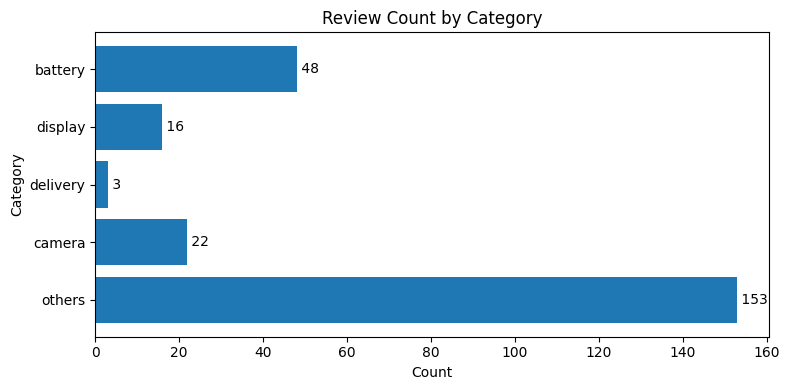

In [13]:
# Horizontal bar chart of review counts by Category from `combined`
# - Uses only matplotlib (no seaborn)
# - Single plot, no custom colors
# - Robust to case/spacing; maps unknown labels to "others"

import pandas as pd
import matplotlib.pyplot as plt

def find_col(df: pd.DataFrame, *candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

# Locate Category column
cat_col = find_col(combined_below3, "Category", "category")
if cat_col is None:
    raise ValueError("Category column not found in `combined`.")

# Normalize categories and count
allowed = ["battery", "display", "delivery", "camera", "others"]
cat_clean = (
    combined_below3[cat_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"": pd.NA})
    .dropna()
)
cat_clean = cat_clean.where(cat_clean.isin(allowed), "others")
counts = cat_clean.value_counts().reindex(allowed, fill_value=0)

# Plot (horizontal bar)
plt.figure(figsize=(8, 4))
bars = plt.barh(counts.index, counts.values)

# Annotate values at the end of each bar
for i, v in enumerate(counts.values):
    plt.text(v, i, f" {v}", va="center")

plt.xlabel("Count")
plt.ylabel("Category")
plt.title("Review Count by Category")
plt.gca().invert_yaxis()  # largest category on top (optional)
plt.tight_layout()
plt.show()


Processing 242 comments with Ollama (gemma3:4b)...


LLM keyword extraction: 100%|██████████| 242/242 [10:09<00:00,  2.52s/it]


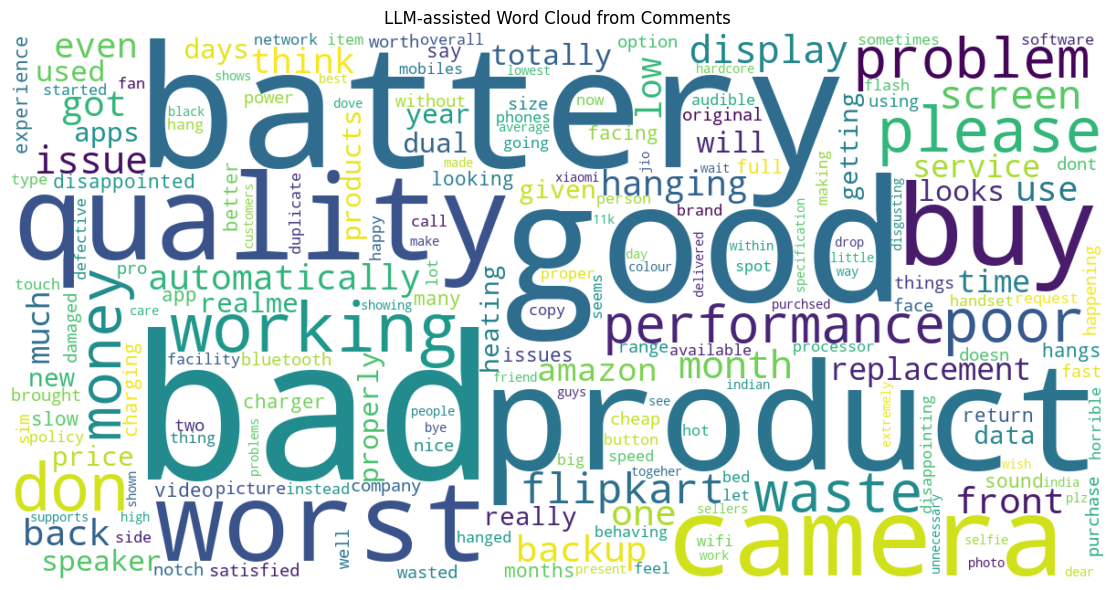

In [14]:
"""
Create a word cloud from the `combined` DataFrame's Comments using Ollama to extract weighted keywords.

What it does:
1) Finds the Comments column (case-insensitive) from `combined`.
2) Calls Ollama per comment to extract 5–10 keywords with weights (JSON).
3) Aggregates weights across all comments.
4) Builds and displays a word cloud (weighted by the LLM’s scores).
5) Falls back to simple keyword heuristic if the LLM call fails.

Requirements:
- pip install wordcloud tqdm
- A running Ollama server with a local model (e.g., gpt-oss:20b or another you prefer).
"""

import os
import re
import json
from collections import Counter, defaultdict

import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# If using Ollama Python package:
# pip install ollama
import ollama


# ------------------------------
# Utilities
# ------------------------------
def find_col(df: pd.DataFrame, *candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None


def get_combined_df():
    """Try to use existing `combined`; if not present, try loading a file."""
    g = globals()
    if "combined_below3" in g and isinstance(g["combined_below3"], pd.DataFrame):
        return g["combined_below3"]
    # fallback: try loading saved combined
    for p in ("./combined_below3.csv", "/mnt/data/combined_below3.csv"):
        if os.path.exists(p):
            return pd.read_csv(p)
    raise RuntimeError("`combined_below3` DataFrame not found. Please define it or place combined_below3.csv in working dir.")


def clean_text_for_prompt(text: str) -> str:
    # Reduce super long text to avoid massive prompts
    if not isinstance(text, str):
        return ""
    t = re.sub(r"\s+", " ", text).strip()
    # Clip excessively long comments
    return t[:1500]


def parse_llm_keywords(raw: str):
    """
    Expecting JSON like:
    {
      "keywords":[
        {"term":"battery life","weight":0.9},
        {"term":"display","weight":0.6}
      ]
    }
    Returns list of (term, weight).
    """
    out = []
    try:
        data = json.loads(raw)
        items = data.get("keywords", [])
        for it in items:
            term = str(it.get("term", "")).strip().lower()
            w = float(it.get("weight", 1.0))
            if term and w > 0:
                out.append((term, w))
    except Exception:
        pass
    return out


def heuristic_keywords(text: str):
    """Simple fallback: extract noun-ish tokens; very rough."""
    if not isinstance(text, str):
        return []
    t = re.sub(r"[^\w\s]", " ", text.lower())
    toks = [w for w in t.split() if len(w) > 2]
    # crude de-dup + tiny weights
    uniq = set(toks)
    return [(w, 0.3) for w in uniq]


# ------------------------------
# Main LLM-assisted wordcloud
# ------------------------------
def build_wordcloud_from_ollama(
    model_name: str = "gpt-oss:20b",
    max_rows: int | None = None,
    temperature: float = 0.0,
    throttle_sec: float = 0.05,
):
    df = get_combined_df()

    # Identify the comment column
    comment_col = find_col(df, "Comments", "comment", "review body", "body", "content")
    if comment_col is None:
        raise ValueError("Comments column not found in `combined_below3`.")

    # Prep comments (drop NaN/empty)
    comments = df[comment_col].astype(str).str.strip()
    comments = comments[comments != ""]
    if max_rows:
        comments = comments.head(max_rows)

    # Track aggregated weights
    weights = defaultdict(float)

    # Optional: small cache if many duplicates
    cache = {}

    print(f"Processing {len(comments)} comments with Ollama ({model_name})...")
    for idx, text in tqdm(list(comments.items()), desc="LLM keyword extraction"):
        txt = clean_text_for_prompt(text)
        if not txt:
            continue

        if txt in cache:
            pairs = cache[txt]
        else:
            prompt = (
                "You analyze smartphone product review comments and extract concise keywords.\n"
                "Return STRICT JSON with this schema:\n"
                "{\n"
                '  "keywords": [\n'
                '    {"term": "<keyword-1>", "weight": <0.1-1.0>},\n'
                '    {"term": "<keyword-2>", "weight": <0.1-1.0>}\n'
                "  ]\n"
                "}\n\n"
                "Rules:\n"
                "- 5 to 10 keywords max.\n"
                "- Keep terms short (1-3 words), no punctuation.\n"
                "- weight in [0.1, 1.0], higher = more important in this comment.\n"
                "- Focus on aspects (battery, display/screen, delivery/shipping, camera/photos, performance, heating, etc.).\n"
                "- Respond with JSON ONLY. No other text.\n\n"
                f"Comment: \"{txt}\""
            )

            try:
                resp = ollama.generate(
                    model=model_name,
                    prompt=prompt,
                    options={"temperature": temperature},
                )
                raw = (resp.get("response") or "").strip()
                pairs = parse_llm_keywords(raw)
                # If parsing failed or empty, use heuristic
                if not pairs:
                    pairs = heuristic_keywords(txt)
            except Exception:
                pairs = heuristic_keywords(txt)

            cache[txt] = pairs

        for term, w in pairs:
            # Basic cleanup: collapse spaces, strip digits-only tokens
            term = re.sub(r"\s+", " ", term).strip()
            if not term or term.isdigit():
                continue
            weights[term] += float(w)

        # polite throttle (especially for larger models)
        if throttle_sec > 0:
            import time
            time.sleep(throttle_sec)

    # Remove generic stopwords and very short terms
    stop = set(STOPWORDS) | {"phone", "mobile", "smartphone", "mi", "redmi", "device"}
    weights = {k: v for k, v in weights.items() if k not in stop and len(k) > 2}

    if not weights:
        raise RuntimeError("No keywords extracted. Check your model name or comments content.")

    # Build word cloud (weighted frequencies)
    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        collocations=False,
        prefer_horizontal=0.9,
        max_words=200,
    ).generate_from_frequencies(weights)

    # Show
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("LLM-assisted Word Cloud from Comments")
    plt.tight_layout()
    plt.show()

    # Optionally return weights and wc object for debugging/saving
    return weights, wc


# ------------------------------
# Example run
# ------------------------------
weights, wc = build_wordcloud_from_ollama(
    model_name="gemma3:4b",  # change this to your local model if needed
    max_rows=None,             # or set a small number to test quickly (e.g., 100)
    temperature=0.0,           # deterministic
    throttle_sec=0.05,         # be nice to your local model
)


In [15]:
import pandas as pd
import re

def find_col(df: pd.DataFrame, *cands):
    lower = {c.lower(): c for c in df.columns}
    for c in cands:
        if c.lower() in lower:
            return lower[c.lower()]
    return None

# Locate columns
rating_col = find_col(combined, "Rating", "rating")
cat_col    = find_col(combined, "Category", "category")
if rating_col is None or cat_col is None:
    raise ValueError("Need Rating and Category columns in `combined`.")

# Numeric rating extracted from strings like "4.0 out of 5 stars"
rating_num = (
    combined[rating_col]
    .astype(str)
    .str.extract(r"([-+]?\d*\.?\d+)")[0]
    .pipe(pd.to_numeric, errors="coerce")
)

# Category normalized
cat_clean = combined[cat_col].astype(str).str.strip().str.lower()

# Mask: Rating < 3 AND Category == "camera"
mask = (rating_num < 3) & (cat_clean == "camera")

# Build filtered df WITHOUT resetting index first
df_camera_below3 = combined.loc[mask].copy()

# Overwrite the Rating column using the SAME mask index (no misalignment)
df_camera_below3[rating_col] = (
    rating_num.loc[mask]          # aligned to original mask index
    .round(0)                     # optional
    .astype("Int64")              # nullable integer
    .values
)

# Now if you want a clean index, reset AFTER the aligned assignment
df_camera_below3.reset_index(drop=True, inplace=True)

# (Optional) keep only certain columns
# df_camera_below3 = df_camera_below3[["Review Title", rating_col, cat_col, "Comments"]]


In [16]:
df_camera_below3

,Review Title,Rating,Category,Comments,Category Prompt,Category LLM Result
0,Bad camera,2,Camera,Bad camera quality and heating problem,<NA>,<NA>
1,Bad camera,2,Camera,Bad camera quality and heating problem,<NA>,<NA>
2,Weste of money,1,Camera,Both Camera quality is bed.its price is too hi...,<NA>,<NA>
3,Worst front camera on a Mi device till date.,1,Camera,It has a worst front camera I have ever seen o...,<NA>,<NA>
4,#Horrible experience of Redmi 6pro - Readon to...,1,Camera,Please don't buy!!\r\n\r\nHorrible phone from ...,<NA>,<NA>
5,Worst Camera,2,Camera,Front camera of this phone is like a VGA camer...,<NA>,<NA>
6,Not worth the money paid. Worst camera & scree...,1,Camera,Camera is too worst considering price of the p...,<NA>,<NA>
7,This Time Mi cheats..,1,Camera,A very worst mobile in such a BiG cost paid.. ...,<NA>,<NA>
8,"Very Terrible, Worst Smartphone.",1,Camera,"Looks is poor. Very bad Performance, Camera qu...",<NA>,<NA>
9,"Very Terrible, Worst Smartphone.",1,Camera,"Looks is poor. Very bad Performance, Camera qu...",<NA>,<NA>


Ollama battery issue extraction: 100%|██████████| 48/48 [02:08<00:00,  2.67s/it]


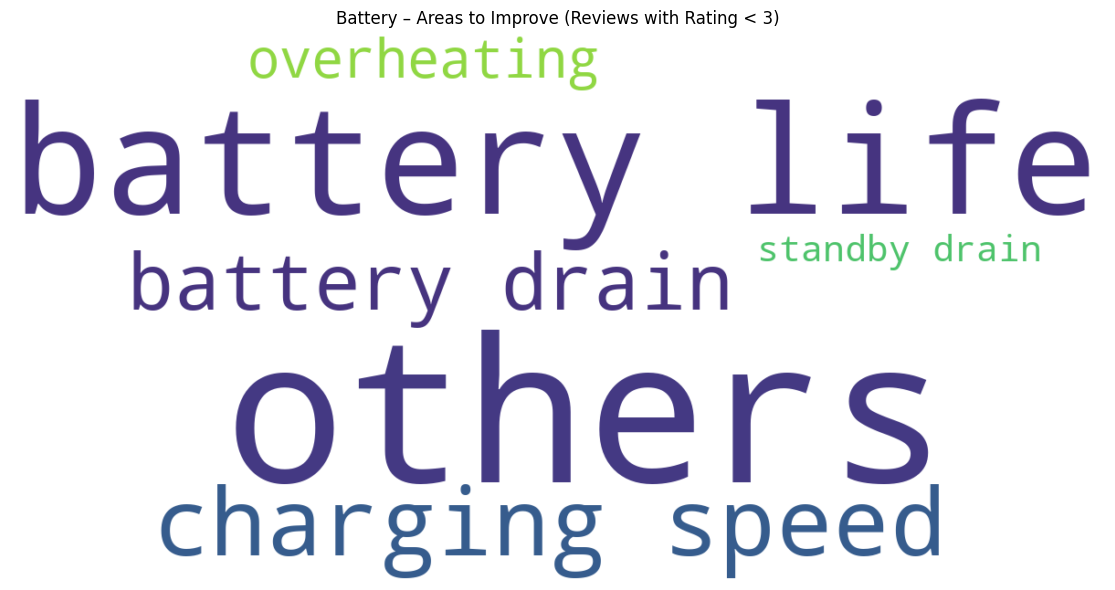

others                    7.80
battery life              6.60
charging speed            4.20
battery drain             3.50
overheating               1.40
standby drain             0.50


In [17]:
"""
Word cloud of "areas to improve" for BATTERY reviews from `combined_below3`,
using Ollama to extract weighted improvement keywords from the Comments.

Requirements:
    pip install wordcloud tqdm ollama
    (Make sure your Ollama server is running; change model_name if needed.)
"""

import re
import json
import time
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from wordcloud import WordCloud, STOPWORDS
import ollama

# -----------------------------
# Config
# -----------------------------
model_name   = "gemma3:4b"   # change to your local model if needed
temperature  = 0.0             # deterministic output
throttle_sec = 0.05            # be gentle to local model
MAX_ROWS     = None            # e.g., 200 for a quick test; None = use all

# -----------------------------
# Utilities
# -----------------------------
def find_col(df: pd.DataFrame, *candidates):
    m = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in m:
            return m[cand.lower()]
    return None

def clean_for_prompt(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = re.sub(r"\s+", " ", text).strip()
    return t[:1500]

def parse_llm_json(raw: str):
    """
    Expect JSON:
    {
      "keywords":[
        {"term":"<short-issue-or-improvement>", "weight":0.1-1.0},
        ...
      ]
    }
    Returns list[(term, weight)]
    """
    out = []
    try:
        data = json.loads(raw)
        for it in data.get("keywords", []):
            term = str(it.get("term", "")).strip().lower()
            w = float(it.get("weight", 1.0))
            if term and w > 0:
                # normalize spaces and strip non-letters at ends
                term = re.sub(r"\s+", " ", term).strip(" .,_-")
                out.append((term, w))
    except Exception:
        pass
    return out

def fallback_heuristics(text: str):
    """Very simple fallback for battery-related issues."""
    if not isinstance(text, str):
        return []
    t = text.lower()
    hits = []
    # (term, weight) pairs
    if any(k in t for k in ["drain", "draining", "drops quickly", "battery dies"]):
        hits.append(("battery drain", 0.7))
    if any(k in t for k in ["backup", "life", "lasts", "lasting", "runtime"]):
        hits.append(("battery life", 0.6))
    if any(k in t for k in ["charge", "charging", "charger", "slow charge", "fast charge"]):
        hits.append(("charging speed", 0.6))
    if any(k in t for k in ["overheat", "heating", "hot"]):
        hits.append(("overheating", 0.7))
    if any(k in t for k in ["standby", "idle"]):
        hits.append(("standby drain", 0.5))
    if any(k in t for k in ["optimiz", "bloat", "background app"]):
        hits.append(("power optimization", 0.5))
    if not hits:
        hits.append(("others", 0.3))
    return hits

# -----------------------------
# 1) Select BATTERY comments from combined_below3
# -----------------------------
cat_col = find_col(combined_below3, "Category", "category")
com_col = find_col(combined_below3, "Comments", "comment", "review body", "body", "content")
if cat_col is None or com_col is None:
    raise ValueError("Need 'Category' and 'Comments' columns in combined_below3.")

battery_mask = combined_below3[cat_col].astype(str).str.strip().str.lower() == "battery"
comments = combined_below3.loc[battery_mask, com_col].astype(str).str.strip()
comments = comments[comments != ""]
if MAX_ROWS:
    comments = comments.head(MAX_ROWS)

# -----------------------------
# 2) LLM extraction (weighted improvement keywords)
# -----------------------------
weights = defaultdict(float)
cache   = {}  # avoid re-calling for duplicate comments

for _, text in tqdm(list(comments.items()), desc="Ollama battery issue extraction"):
    txt = clean_for_prompt(text)
    if not txt:
        continue

    if txt in cache:
        pairs = cache[txt]
    else:
        prompt = (
            "You analyze smartphone BATTERY-related review comments and extract concise improvement areas.\n"
            "Return STRICT JSON only with this schema:\n"
            "{\n"
            '  "keywords": [\n'
            '    {"term":"<short-issue-or-improvement>", "weight":0.1-1.0},\n'
            '    {"term":"<short-issue-or-improvement>", "weight":0.1-1.0}\n'
            "  ]\n"
            "}\n\n"
            "Rules:\n"
            "- 3 to 8 items only; avoid duplicates; keep terms 1–3 words.\n"
            "- Focus on battery-specific improvement points (e.g., battery life, charging speed, overheating,\n"
            "  standby drain, power optimization, calibration, fast charging support, charger quality).\n"
            "- Weight reflects urgency/importance (higher = stronger need to improve).\n"
            "- JSON ONLY. No extra text.\n\n"
            f"Comment: \"{txt}\""
        )
        try:
            resp = ollama.generate(
                model=model_name,
                prompt=prompt,
                options={"temperature": temperature},
            )
            raw = (resp.get("response") or "").strip()
            pairs = parse_llm_json(raw)
            if not pairs:
                pairs = fallback_heuristics(txt)
        except Exception:
            pairs = fallback_heuristics(txt)

        cache[txt] = pairs

    for term, w in pairs:
        if term:
            weights[term] += float(w)

    if throttle_sec > 0:
        time.sleep(throttle_sec)

# -----------------------------
# 3) Clean stopwords and tiny tokens
# -----------------------------
stop = set(STOPWORDS) | {"phone", "mobile", "smartphone", "redmi", "mi", "device"}
freqs = {k: v for k, v in weights.items() if k not in stop and len(k) > 2}
if not freqs:
    raise RuntimeError("No keywords extracted; check model/inputs.")

# -----------------------------
# 4) Build + show word cloud (matplotlib; no custom colors)
# -----------------------------
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False,
    prefer_horizontal=0.9,
    max_words=200,
).generate_from_frequencies(freqs)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Battery – Areas to Improve (Reviews with Rating < 3)")
plt.tight_layout()
plt.show()

# (Optional) peek at top issues
top_issues = sorted(freqs.items(), key=lambda x: x[1], reverse=True)[:20]
for k, v in top_issues:
    print(f"{k:24s}  {v:.2f}")


Ollama camera issue extraction: 100%|██████████| 22/22 [01:01<00:00,  2.81s/it]


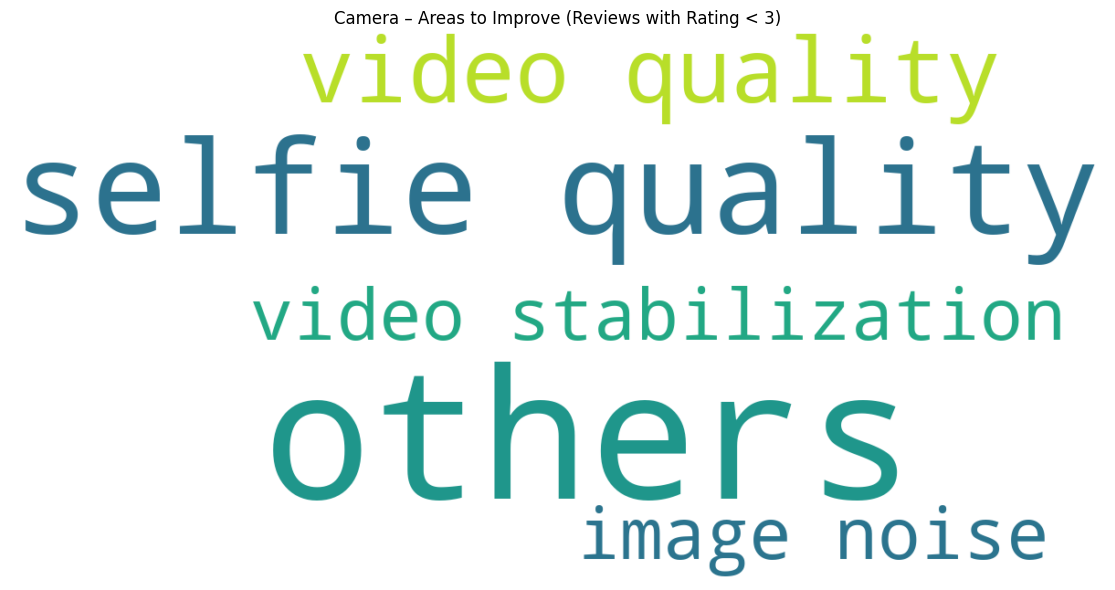

others                        4.80
selfie quality                2.50
video quality                 1.00
image noise                   0.60
video stabilization           0.60


In [18]:
"""
Word cloud of "areas to improve" for CAMERA reviews from `combined_below3`,
using Ollama to extract weighted improvement keywords from the Comments.

Requirements:
    pip install wordcloud tqdm ollama
    (Ensure your Ollama server is running; change `model_name` if needed.)
"""

import re
import json
import time
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from wordcloud import WordCloud, STOPWORDS
import ollama

# -----------------------------
# Config
# -----------------------------
model_name   = "gemma3:4b"   # change to a local model you have
temperature  = 0.0             # deterministic output
throttle_sec = 0.05            # be gentle to local model
MAX_ROWS     = None            # e.g., 200 for a quick test; None = use all

# -----------------------------
# Utilities
# -----------------------------
def find_col(df: pd.DataFrame, *candidates):
    m = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in m:
            return m[cand.lower()]
    return None

def clean_for_prompt(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = re.sub(r"\s+", " ", text).strip()
    return t[:1500]

def parse_llm_json(raw: str):
    """
    Expect JSON:
    {
      "keywords":[
        {"term":"<short-issue-or-improvement>", "weight":0.1-1.0},
        ...
      ]
    }
    Returns list[(term, weight)]
    """
    out = []
    try:
        data = json.loads(raw)
        for it in data.get("keywords", []):
            term = str(it.get("term", "")).strip().lower()
            w = float(it.get("weight", 1.0))
            if term and w > 0:
                term = re.sub(r"\s+", " ", term).strip(" .,_-")
                out.append((term, w))
    except Exception:
        pass
    return out

def fallback_heuristics(text: str):
    """Simple camera-issue fallback."""
    if not isinstance(text, str):
        return []
    t = text.lower()
    hits = []
    add = hits.append
    if any(k in t for k in ["blurry", "blur", "focus", "autofocus", "out of focus", "shutter lag"]):
        add(("focus / blur", 0.7))
    if any(k in t for k in ["low light", "night", "dark"]):
        add(("low-light performance", 0.7))
    if any(k in t for k in ["noise", "grain", "noisy"]):
        add(("image noise", 0.6))
    if any(k in t for k in ["color", "colour", "saturation", "white balance"]):
        add(("color accuracy", 0.5))
    if any(k in t for k in ["hdr", "dynamic range"]):
        add(("dynamic range / hdr", 0.6))
    if any(k in t for k in ["stabilization", "ois", "eis", "shake", "shaky"]):
        add(("video stabilization", 0.6))
    if any(k in t for k in ["selfie", "front camera"]):
        add(("selfie quality", 0.5))
    if any(k in t for k in ["video", "record", "recording"]):
        add(("video quality", 0.5))
    if not hits:
        add(("others", 0.3))
    return hits

# -----------------------------
# 1) Select CAMERA comments from combined_below3
# -----------------------------
cat_col = find_col(combined_below3, "Category", "category")
com_col = find_col(combined_below3, "Comments", "comment", "review body", "body", "content")
if cat_col is None or com_col is None:
    raise ValueError("Need 'Category' and 'Comments' columns in combined_below3.")

camera_mask = combined_below3[cat_col].astype(str).str.strip().str.lower() == "camera"
comments = combined_below3.loc[camera_mask, com_col].astype(str).str.strip()
comments = comments[comments != ""]
if MAX_ROWS:
    comments = comments.head(MAX_ROWS)
if comments.empty:
    raise RuntimeError("No CAMERA comments found in combined_below3.")

# -----------------------------
# 2) LLM extraction (weighted improvement keywords)
# -----------------------------
weights = defaultdict(float)
cache   = {}

for _, text in tqdm(list(comments.items()), desc="Ollama camera issue extraction"):
    txt = clean_for_prompt(text)
    if not txt:
        continue

    if txt in cache:
        pairs = cache[txt]
    else:
        prompt = (
            "You analyze smartphone CAMERA-related review comments and extract concise areas to improve.\n"
            "Return STRICT JSON only with this schema:\n"
            "{\n"
            '  "keywords": [\n'
            '    {"term":"<short-issue-or-improvement>", "weight":0.1-1.0},\n'
            '    {"term":"<short-issue-or-improvement>", "weight":0.1-1.0}\n'
            "  ]\n"
            "}\n\n"
            "Rules:\n"
            "- 3 to 8 items; avoid duplicates; keep terms 1–3 words.\n"
            "- Focus on camera issues like focus/blur, low light, image noise, color accuracy,\n"
            "  dynamic range/HDR, video stabilization, selfie quality, shutter lag, exposure.\n"
            "- Weight reflects urgency/importance (higher = stronger need to improve).\n"
            "- JSON ONLY. No extra text.\n\n"
            f"Comment: \"{txt}\""
        )
        try:
            resp = ollama.generate(
                model=model_name,
                prompt=prompt,
                options={"temperature": temperature},
            )
            raw = (resp.get("response") or "").strip()
            pairs = parse_llm_json(raw)
            if not pairs:
                pairs = fallback_heuristics(txt)
        except Exception:
            pairs = fallback_heuristics(txt)

        cache[txt] = pairs

    for term, w in pairs:
        if term:
            weights[term] += float(w)

    if throttle_sec > 0:
        time.sleep(throttle_sec)

# -----------------------------
# 3) Clean stopwords and tiny tokens
# -----------------------------
stop = set(STOPWORDS) | {"phone", "mobile", "smartphone", "redmi", "mi", "device", "camera", "photo", "picture"}
freqs = {k: v for k, v in weights.items() if k not in stop and len(k) > 2}
if not freqs:
    raise RuntimeError("No keywords extracted; check model/inputs.")

# -----------------------------
# 4) Build + show word cloud (matplotlib; no custom colors set)
# -----------------------------
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False,
    prefer_horizontal=0.9,
    max_words=200,
).generate_from_frequencies(freqs)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Camera – Areas to Improve (Reviews with Rating < 3)")
plt.tight_layout()
plt.show()

# (Optional) top issues preview
top_issues = sorted(freqs.items(), key=lambda x: x[1], reverse=True)[:20]
for k, v in top_issues:
    print(f"{k:28s}  {v:.2f}")
